# VortexTech AI & ML Internship — Week 3

## Regression and Clustering on Real Data

### Project Overview

This project applies supervised and unsupervised machine learning techniques to real-world datasets.

- Regression using California Housing Dataset
- Clustering using Mall Customers Dataset

## Objective

The objective of this project is to work with real-world data using both supervised and unsupervised machine learning techniques.

### Regression Objective

Build a regression model to predict a continuous numeric target using the California Housing dataset.

The regression model will be trained using a proper train/test split and evaluated using:

- RMSE (Root Mean Squared Error)
- R² (R-squared)

### Clustering Objective

Apply K-Means clustering to the Mall Customers dataset to identify groups of customers based on selected numerical features.

The clustering process will include:

- Data scaling using StandardScaler[]
- Elbow method
- Selection of a reasonable number of clusters
- K-Means clustering
- 2D visualization of the resulting clusters

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
print("All libraries imported successfully.")

All libraries imported successfully.


# Part 1 — Regression

## California Housing Dataset

The California Housing dataset is used for the regression task.

The objective is to predict the continuous numeric target `median_house_value` using the available housing-related features.

Linear Regression is selected as the regression algorithm because it is a simple, interpretable model suitable for predicting a continuous numeric target.

In [123]:
housing_df =  pd.read_csv("../data/housing.csv")
print("Housing dataset loaded successfully.")
print("Dataset shape:", housing_df.shape)
housing_df.head()

Housing dataset loaded successfully.
Dataset shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [126]:
print("Column Names:")
print(housing_df.columns.tolist())
print("\nData Types:")
print(housing_df.dtypes)
print("\nMissing Values:")
print(housing_df.isnull().sum())
print("\nDuplicate Rows:")
print(housing_df.duplicated().sum())

Column Names:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Duplicate Rows:
0


## Data Cleaning

The dataset contains 207 missing values in the `total_bedrooms` column and no duplicate rows.

The missing `total_bedrooms` values are handled by replacing them with the median of the column. Median imputation is used because it is less sensitive to extreme values than the mean.

No duplicate rows need to be removed because the dataset contains zero duplicate records.

In [127]:
# Fill missing values in total_bedrooms with the median
housing_df["total_bedrooms"] = housing_df["total_bedrooms"].fillna(
    housing_df["total_bedrooms"].median() )
print("Missing values after cleaning:")
print(housing_df.isnull().sum())
print("\nDuplicate rows:", housing_df.duplicated().sum())

Missing values after cleaning:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Duplicate rows: 0


## Encoding Categorical Features

The `ocean_proximity` column contains categorical values rather than numerical values.

One-hot encoding is used to convert these categories into numerical indicator columns so that the categorical information can be included in the regression model.

In [106]:
# Convert the categorical ocean_proximity column into numerical columns
housing_encoded = pd.get_dummies( housing_df, columns=["ocean_proximity"], drop_first=True )
print("Encoded dataset shape:", housing_encoded.shape)
housing_encoded.head()

Encoded dataset shape: (20640, 13)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


## Feature and Target Selection

The target variable is `median_house_value`.

All remaining columns are used as input features after preprocessing.

The categorical `ocean_proximity` feature has been converted into numerical indicator variables using one-hot encoding.

In [107]:
X = housing_encoded.drop("median_house_value", axis=1)
y = housing_encoded["median_house_value"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (20640, 12)
Target shape: (20640,)

Feature columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


## Train/Test Split

The preprocessed dataset is divided into training and testing sets using an 80/20 split.

The training data will be used to train the Linear Regression model, while the test data will be used to evaluate how well the model performs on unseen observations.

In [108]:
X_train, X_test, y_train, y_test = train_test_split( X,y, test_size=0.20, random_state=42 )
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (16512, 12)
Testing features shape: (4128, 12)
Training target shape: (16512,)
Testing target shape: (4128,)


## Feature Scaling

StandardScaler is used to standardize the numerical input features.

The scaler is fitted only on the training data and then applied to the testing data. This prevents data leakage from the test set into the training process.

In [109]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed.")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed.
Scaled training data shape: (16512, 12)
Scaled testing data shape: (4128, 12)


## Linear Regression Model

Linear Regression is selected because the target variable, `median_house_value`, is a continuous numeric value.

The model learns the relationship between the housing features and the target value using the training dataset.

In [110]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [111]:
y_pred = model.predict(X_test_scaled)
print("Predictions generated successfully.")
print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully.

First 10 predictions:
[ 54055.44889898 124225.33893718 255489.37949166 268002.43156919
 262769.43481568 139606.3039556  290665.42391417 228264.87637529
 256506.78561005 407923.85843486]


## Regression Model Evaluation

The trained Linear Regression model is evaluated using two metrics:

- **RMSE (Root Mean Squared Error):** Measures the typical magnitude of prediction errors. Lower values indicate smaller prediction errors.
- **R² Score:** Measures the proportion of variation in the target variable explained by the model. Higher values indicate that more variation is explained by the model.

In [112]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

RMSE: 70060.52
R² Score: 0.6254


## Actual vs Predicted House Values

The following visualization compares the actual house values from the test dataset with the values predicted by the Linear Regression model.

A strong regression model would have predictions close to the diagonal reference line, where predicted values are approximately equal to actual values.

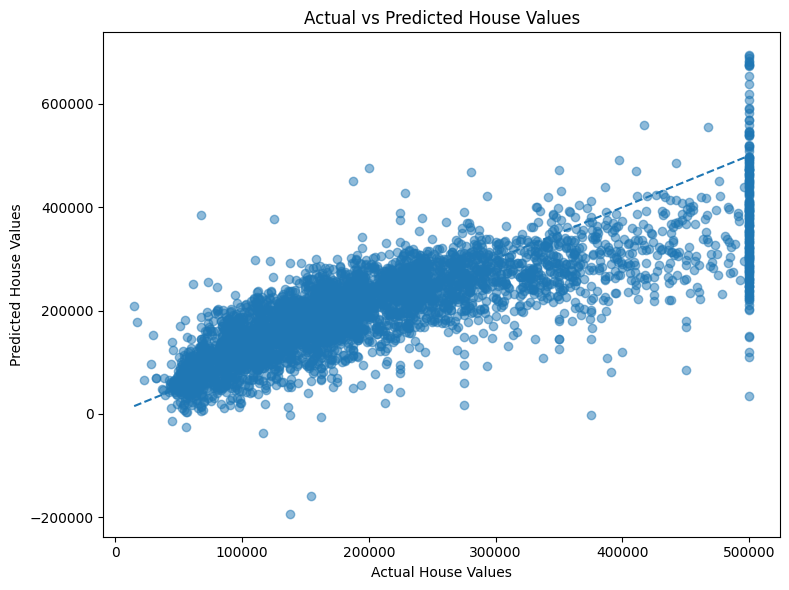

In [113]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Actual vs Predicted House Values")
plt.plot( [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--" )
plt.tight_layout()
plt.show()

## Regression Results and Interpretation

The Linear Regression model achieved an RMSE of **70,060.52** and an R² score of **0.6254** on the test dataset.

The R² score indicates that the model explains approximately **62.54% of the variation** in median house values.

The RMSE indicates that the model's predictions differ from the actual house values by approximately **70,061 dollars on average in terms of error magnitude**.

The actual-versus-predicted plot provides a visual comparison of the model's predictions with the actual values. Predictions closer to the diagonal reference line represent smaller prediction errors.

Overall, the regression model provides a baseline prediction of house values using the available housing features.

# Part 2 — K-Means Clustering

## Mall Customers Dataset

K-Means clustering is used to identify groups of customers with similar characteristics.

For this task, the Mall Customers dataset is used. The clustering analysis will focus on numerical customer features and will not use the customer ID as a clustering feature.

The elbow method will be used to determine a reasonable number of clusters before training the final K-Means model.

In [114]:
mall_df = pd.read_csv("../data/Mall_Customers.csv")
print("Mall Customers dataset loaded successfully.")
print("Dataset shape:", mall_df.shape)
mall_df.head()

Mall Customers dataset loaded successfully.
Dataset shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [115]:
print("Column Names:")
print(mall_df.columns.tolist())
print("\nData Types:")
print(mall_df.dtypes)
print("\nMissing Values:")
print(mall_df.isnull().sum())
print("\nDuplicate Rows:")
print(mall_df.duplicated().sum())

Column Names:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows:
0


## Selecting Features for Clustering

For K-Means clustering, three numerical customer features are selected:

- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

`CustomerID` is excluded because it is only an identifier and does not represent a meaningful customer characteristic.

The categorical `Genre` column is also excluded because this clustering analysis focuses on numerical customer characteristics.

In [116]:
clustering_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X_cluster = mall_df[clustering_features]
print("Selected clustering features:")
print(X_cluster.columns.tolist())
print("\nClustering data shape:", X_cluster.shape)
X_cluster.head()

Selected clustering features:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Clustering data shape: (200, 3)


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


## Feature Scaling

K-Means clustering is distance-based, so features with larger numerical ranges can have a greater influence on the clustering process.

StandardScaler is used to standardize the selected features so that they are on a comparable scale.

In [117]:
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)
print("Clustering features scaled successfully.")
print("Scaled data shape:", X_cluster_scaled.shape)

Clustering features scaled successfully.
Scaled data shape: (200, 3)


## Determining the Number of Clusters — Elbow Method

The Elbow Method is used to determine a reasonable number of clusters for K-Means.

K-Means models are tested with cluster counts from 1 to 10. For each value of K, the inertia (within-cluster sum of squares) is recorded.

The point where the decrease in inertia begins to slow down significantly is considered the elbow and provides a reasonable choice for the number of clusters.

In [118]:
inertia_values = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10 )
    kmeans.fit(X_cluster_scaled)
    inertia_values.append(kmeans.inertia_)
print("Inertia values:")
for i in range(len(inertia_values)):
    print(f"K={i+1}: {inertia_values[i]:.2f}")

Inertia values:
K=1: 600.00
K=2: 389.39
K=3: 295.21
K=4: 205.23
K=5: 168.25
K=6: 133.87
K=7: 117.01
K=8: 103.87
K=9: 93.09
K=10: 82.39


## Elbow Method Visualization

The inertia values are plotted against the number of clusters.

The elbow point is identified by observing where the reduction in inertia begins to slow down. This provides a reasonable number of clusters for the final K-Means model.

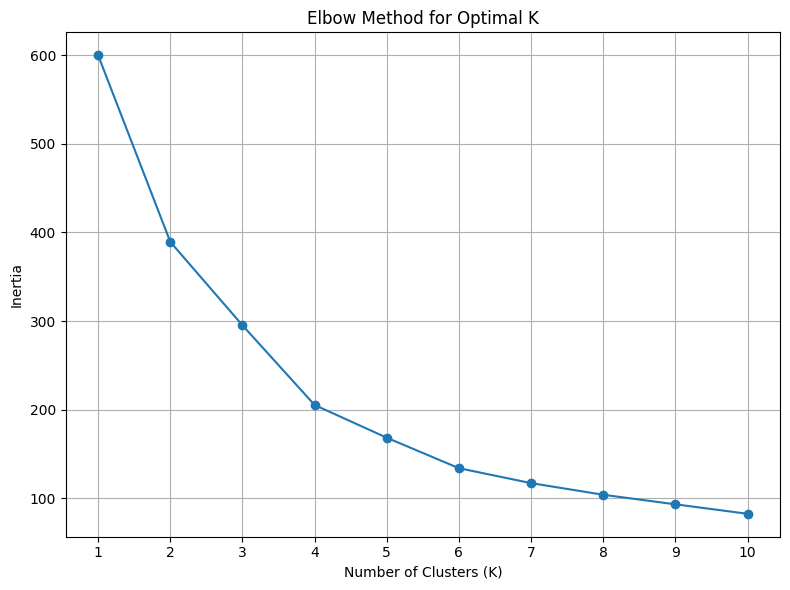

In [119]:
k_values = range(1, 11)
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia_values, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

## Choosing the Number of Clusters

Based on the elbow plot, **K = 4** is selected as a reasonable number of clusters.

The inertia decreases substantially as the number of clusters increases from 1 to 4. After K = 4, the reduction in inertia becomes more gradual.

Therefore, four clusters provide a reasonable balance between reducing within-cluster variation and keeping the number of customer groups manageable.

In [120]:
clustering_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X_cluster = mall_df[clustering_features]
print("Selected clustering features:")
print(X_cluster.columns.tolist())
print("\nClustering data shape:", X_cluster.shape)
X_cluster.head()

Selected clustering features:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Clustering data shape: (200, 3)


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [121]:
final_kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
cluster_labels = final_kmeans.fit_predict(X_cluster_scaled)
mall_df["Cluster"] = cluster_labels
print("Final K-Means model trained successfully.")
print("\nCluster counts:")
print(mall_df["Cluster"].value_counts().sort_index())

Final K-Means model trained successfully.

Cluster counts:
Cluster
0    65
1    40
2    57
3    38
Name: count, dtype: int64


## 2D Visualization of Customer Clusters

The customer clusters are visualized in two dimensions using `Annual Income (k$)` and `Spending Score (1-100)`.

Each point represents one customer, and the point's cluster assignment is represented by its color.

This visualization helps show how customers are separated based on their income and spending behavior.

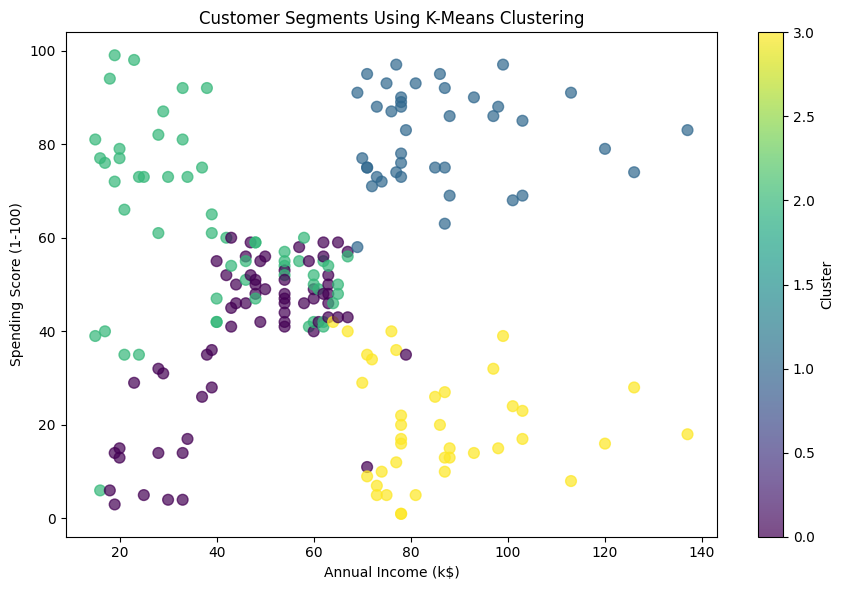

In [124]:
plt.figure(figsize=(9, 6))
plt.scatter(
mall_df["Annual Income (k$)"],
mall_df["Spending Score (1-100)"],
c=mall_df["Cluster"],
s=60,
alpha=0.7 )
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments Using K-Means Clustering")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()

## Cluster Characteristics

To understand the customer groups, the average age, annual income, and spending score are calculated for each cluster.

These averages help interpret the general characteristics and spending behavior of the customers within each group.

In [125]:
cluster_summary = mall_df.groupby("Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"] ].mean().round(2)
print("Average characteristics of each cluster:")
cluster_summary

Average characteristics of each cluster:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,53.98,47.71,39.97
1,32.88,86.10,81.53
2,25.44,40.00,60.30
3,39.37,86.50,19.58


## Real-World Interpretation of Customer Clusters

The four customer clusters show different combinations of age, annual income, and spending score.

- **Cluster 0:** Customers have a relatively higher average age (53.98), moderate average annual income (47.71 k$), and moderate spending score (39.97). This group represents relatively older customers with moderate income and moderate spending behavior.

- **Cluster 1:** Customers have a younger average age (32.88), high average annual income (86.10 k$), and high spending score (81.53). This group represents younger customers with higher income and high spending activity.

- **Cluster 2:** Customers have the lowest average age (25.44), lower average annual income (40.00 k$), and a moderately high spending score (60.30). This group represents younger customers with lower income but relatively active spending behavior.

- **Cluster 3:** Customers have an average age of 39.37, high average annual income (86.50 k$), and a low spending score (19.58). This group represents customers with higher income but relatively low spending activity.

These clusters provide a simplified segmentation of customers based on age, income, and spending behavior. In a real-world business setting, such segments could be used to support customer analysis and targeted marketing strategies.

# Conclusion

This project applied both supervised and unsupervised machine learning techniques to real-world datasets.

### Regression

A Linear Regression model was trained on the California Housing dataset to predict `median_house_value`.

The model achieved:

- **RMSE:** 70,060.52
- **R² Score:** 0.6254

The model explains approximately 62.54% of the variation in the test-set target values.

### Clustering

K-Means clustering was applied to the Mall Customers dataset using:

- Age
- Annual Income (k$)
- Spending Score (1-100)

The Elbow Method was used to evaluate K values from 1 to 10, and **K = 4** was selected as a reasonable number of clusters.

The final clustering model identified four customer segments with different age, income, and spending characteristics.

This project demonstrates the complete workflow of data cleaning, preprocessing, supervised regression, model evaluation, unsupervised clustering, visualization, and interpretation.